Fit second degree curve $y=a + b x + c x^2$

In [162]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import Math
from sympy import latex
from pandas import DataFrame
import pandas as pd
np.set_printoptions(suppress=True, precision=4)

In [163]:
# x = list(map(float, input("Input data points $x$: ").split()))
# y = list(map(float, input("Input corresponding data points for y: ").split()))

x = [1, 1.5, 2, 2.5, 3, 3.5, 5]
y = [1.1, 1.3, 1.6, 2, 2.7, 3.4, 4.1]

In [164]:
if len(x)!=len(y):
    display(Math("Number of $x$-data and $y$-data must be equal!"))

n = len(x)

print("Data points are: ")
display(pd.DataFrame({"x": x, "y": y}).T)

Data points are: 


,0,1,2,3,4,5,6
x,1.0,1.5,2.0,2.5,3.0,3.5,5.0
y,1.1,1.3,1.6,2.0,2.7,3.4,4.1


Building coefficinet matrix

In [165]:
# A = np.zeros((n, n))
# for i in range(n):
#     for j in range(n):
#         A[i][j] = sum(x[i]**k for k in range(n-j-1, n-1),)
x = np.array(x, dtype=float)
A = np.array([
    [len(x), np.sum(x),     np.sum(x**2)],
    [np.sum(x), np.sum(x**2), np.sum(x**3)],
    [np.sum(x**2), np.sum(x**3), np.sum(x**4)]
], dtype=float)

print("Coefficient matrix is: ")
# print(pd.DataFrame(A))
print(A)
display(Math(latex(sp.Matrix(A))))

Coefficient matrix is: 
[[  7.      18.5     59.75  ]
 [ 18.5     59.75   222.875 ]
 [ 59.75   222.875  917.1875]]


<IPython.core.display.Math object>

Building output matrix

In [166]:
B = np.array(y, dtype=float).reshape(n, 1)

B=[[sum(y)], [sum(x*y)], [sum(x**2 * y)]]
print("Column vector of $y$-data is: ")
print(B)
display(Math(latex(sp.Matrix)))

Column vector of $y$-data is: 
[[16.2], [51.75], [191.375]]


<IPython.core.display.Math object>

In [167]:
coff = np.linalg.solve(A, B)
print(coff)
display(Math(latex(sp.Matrix(coff))))

[[-0.0071]
 [ 0.9432]
 [-0.0201]]


<IPython.core.display.Math object>

In [168]:
a = coff[0]
b = coff[1]
c = coff[2]

Print 2nd order ploynomial

In [169]:
display(Math(f"y={a[0]:.4f} + {b[0]:.4f} x + {c[0]:.4f} x^2"))
# print(f"y = {a[0]:.4f} + {b[0]:.4f}x + {c[0]:.4f}x^2")

<IPython.core.display.Math object>

Plot line: $X$ vs $ y = a + b x + c^2$

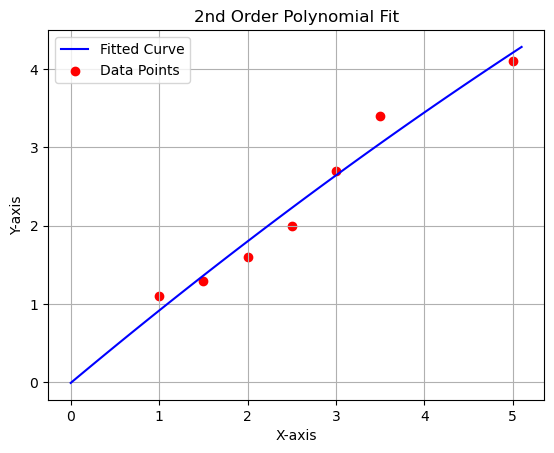

In [170]:
X = np.linspace(min(x)-1, max(y)+1, 100)
# plt.plot(w, P(w), label=exp)
Y = a[0] + b[0] * X + c[0] * X**2
plt.plot(X, Y, label="Fitted Curve", color="blue")
plt.scatter(x, y, label="Data Points", color="red")
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('2nd Order Polynomial Fit')
plt.legend()
plt.grid(True)
plt.show()
